In [131]:
import numpy as np
from matplotlib import pyplot as plt
from cycler import cycler
plt.rc('axes', prop_cycle=cycler(color=['0.0', '0.4', '0.8']))
import matplotlib; matplotlib.rcParams.update({'font.size': 18})

In [132]:
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
from IPython.display import HTML
import course_helpers as chh
apply_beamer_theme(
    "madrid",
    skip_font_download=True,
    author="Robert Pettis",
    date="Fall 2026",
    show_slide_number=True,
    cell_tags=True,
    notebook_path="07-Regularization-Ridge-and-Lasso.ipynb",
)

<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 24 cell(s):
 cell_index   slide_id                                  tags
          3            slide_hide_prompt, slide_remove_input
          8  slide-1-0 slide_hide_prompt, slide_remove_input
         10  slide-2-0 slide_hide_prompt, slide_remove_input
         12  slide-2-1 slide_hide_prompt, slide_remove_input
         14  slide-3-0 slide_hide_prompt, slide_remove_input
         17  slide-4-1 slide_hide_prompt, slide_remove_input
         19  slide-4-2 slide_hide_prompt, slide_remove_input
         22  slide-6-0 slide_hide_prompt, slide_remove_input
         25  slide-7-0 slide_hide_prompt, slide_remove_input
         35  slide-9-2 slide_hide_prompt, slide_remove_input
         37  slide-9-3 slide_hide_prompt, slide_remove_input
         39  slide-9-4 slide_hide_prompt, slide_remove_input
         44  slide-9-8 slide_hide_prompt, slide_remove_input
         47 slide-9-10 slide_hide_prompt, slide_remove_input
         49 slide-9-11 slide_hide_prompt, sli

In [133]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed

In [134]:
from sklearn.linear_model import Ridge
# The firm, the two lines, the palette. Every figure below draws from these.
import numpy as np
import matplotlib.pyplot as plt

LSQ   = "#B3121F"      # least squares, red, as in the video
RIDGE = "#2A6FD6"      # ridge, blue
LASSO = "#E08A1E"      # lasso, orange
TEST  = "#3F9B3F"      # data the line has never seen, green
INK   = "#1A1A1A"
GREY  = "#9A9A9A"
GRID  = "#C4C4D0"

# a year of months: ad spend and sales, both in $000
AD    = np.array([0.6, 1.1, 1.5, 1.9, 2.3, 2.9, 3.2, 3.6, 4.0])
SALES = np.array([1.28, 1.83, 1.94, 2.42, 2.51, 4.17, 3.35, 3.52, 3.98])

FULL_A, FULL_B = 0.9, 0.75          # the line least squares gives on all of it
TWO = np.array([1, 5])              # the two months we will pretend we have
TR_A, TR_B = 0.4, 1.3               # the line least squares gives on those two

def firm_axes(ax, xmax=4.4, ymax=5.0):
    ax.set_xlim(0, xmax); ax.set_ylim(0, ymax)
    ax.set_xlabel("ad spend, $000", fontsize=13)
    ax.text(0.0, 1.03, "sales, $000", transform=ax.transAxes, ha="left",
            va="bottom", fontsize=13, color=INK)
    ax.grid(True, color=GRID, lw=0.7); ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

def panel(w=10.6, h=4.4):
    fig, ax = plt.subplots(figsize=(w, h))
    fig.subplots_adjust(left=0.09, right=0.97, top=0.9, bottom=0.17)
    return fig, ax

<div class="beamer-meta" data-author="Robert Pettis" data-date="Fall 2026"></div>

# Regularization

### Ridge, lasso, and paying a price for a steep slope

Causal Machine Learning

<br>

<b style="color:#73000A;">Robert Pettis</b>
Fall 2026

## Before We Start: Updating Your Repo

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Reminder</span> &nbsp;same git rhythm as the setup lecture.

| command | what it does |
|---|---|
| `git pull upstream main` | grab today's lecture before class |
| `git checkout -b ps1` | a branch for your own work |
| `git add .` then `git commit -m "..."` | snapshot your changes |
| `git push origin ps1` | send it to your fork, then open a pull request |
| `git status` | what changed, any time |

### Where This Goes

1. A small example that shows the main idea behind <b style="color:#73000A;">ridge regression</b>
2. The details of how it works
3. How it works in a <b style="color:#73000A;">variety of situations</b>
4. How it can solve the unsolvable

## Start With Some Data

A shop's monthly <b style="color:#73000A;">ad spend</b> and its <b style="color:#73000A;">sales</b>, both in thousands of
dollars. The relationship looks straight, so fit a line by least squares.

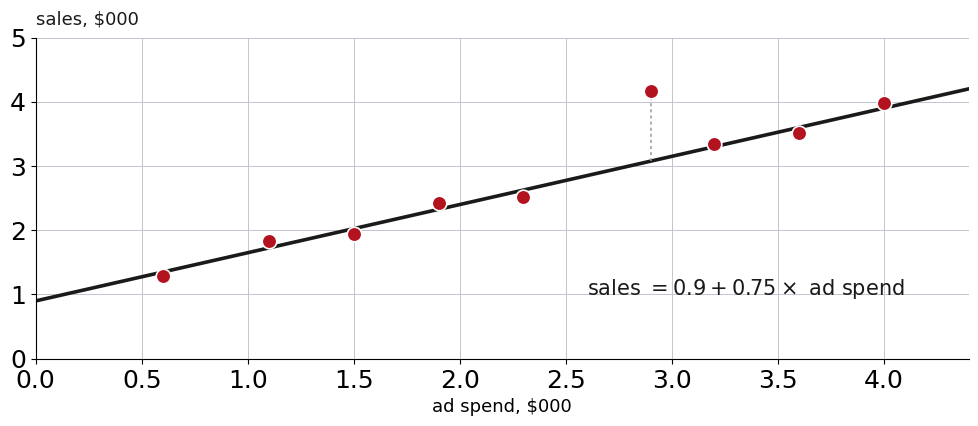

spend 2.5  ->  sales = 0.9 + 0.75 x 2.5 = 2.77


In [135]:
fig, ax = panel()
firm_axes(ax)
grid = np.linspace(0, 4.4, 50)
ax.plot(grid, FULL_A + FULL_B * grid, color=INK, lw=2.6)
ax.scatter(AD, SALES, s=110, color=LSQ, edgecolors="white", lw=1.2, zorder=5)
for x, y in zip(AD, SALES):
    ax.plot([x, x], [y, FULL_A + FULL_B * x], color=GREY, lw=1.1, ls=(0, (2, 2)))
ax.text(2.6, 1.0, "sales $= 0.9 + 0.75 \\times$ ad spend", fontsize=15, color=INK)
plt.show()

spend = 2.5
print("spend %.1f  ->  sales = 0.9 + 0.75 x %.1f = %.2f" % (spend, spend, FULL_A + FULL_B * spend))

## But What if You Only Have Two Months?

New shop. Two months of data. Fit a line by least squares to those two points.

The line <b style="color:#73000A;">goes through both of them exactly</b>, so the sum of squared residuals
is <b style="color:#73000A;">zero</b>.

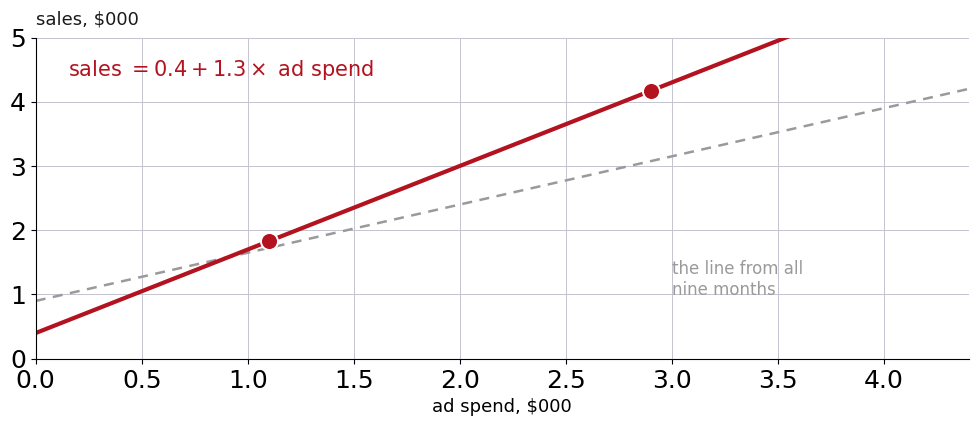

the two months:       [1.83 4.17]
what the line says:   [1.83 4.17]
sum of squared residuals: 0.00


In [136]:
fig, ax = panel()
firm_axes(ax)
grid = np.linspace(0, 4.4, 50)
ax.plot(grid, FULL_A + FULL_B * grid, color=GREY, lw=1.8, ls=(0, (4, 3)))
ax.plot(grid, TR_A + TR_B * grid, color=LSQ, lw=3)
ax.scatter(AD[TWO], SALES[TWO], s=150, color=LSQ, edgecolors="white", lw=1.4, zorder=6)
ax.text(0.15, 4.4, "sales $= 0.4 + 1.3 \\times$ ad spend", fontsize=15, color=LSQ)
ax.text(3.0, 1.0, "the line from all\nnine months", fontsize=12, color=GREY)
plt.show()

fit = TR_A + TR_B * AD[TWO]
print("the two months:      ", np.round(SALES[TWO], 2))
print("what the line says:  ", np.round(fit, 2))
print("sum of squared residuals: %.2f" % np.sum((SALES[TWO] - fit) ** 2))

### Training Data and Testing Data

Call the two red months the <b style="color:#73000A;">training data</b> and the rest the
<b style="color:#73000A;">testing data</b>.

- The sum of squared residuals for the two red months is <b style="color:#73000A;">zero</b>
- The sum of squared residuals for the green months is <b style="color:#73000A;">large</b>

A line that fits its own data perfectly and misses everything else has
<b style="color:#73000A;">high variance</b>. In machine learning lingo, it is
<b style="color:#73000A;">overfit</b> to the training data.

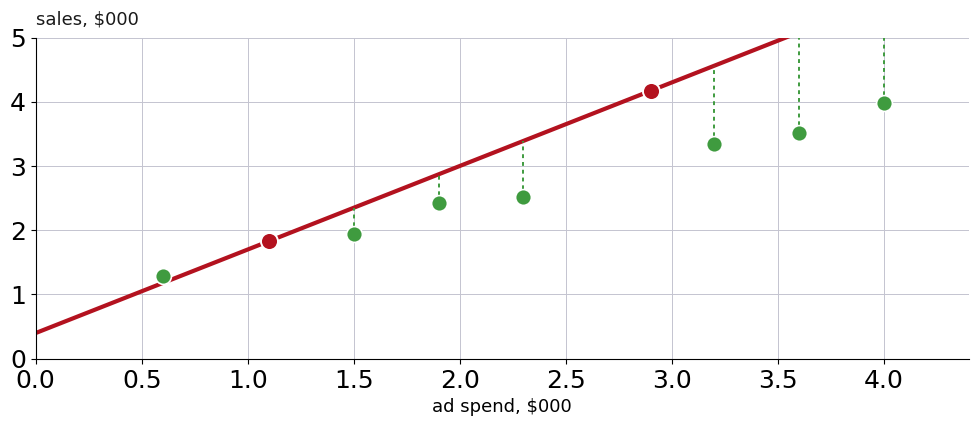

sum of squared residuals, the two training months:   0.00
sum of squared residuals, the seven testing months:   7.68


In [137]:
fig, ax = panel()
firm_axes(ax)
grid = np.linspace(0, 4.4, 50)
ax.plot(grid, TR_A + TR_B * grid, color=LSQ, lw=3)
rest = np.array([i for i in range(len(AD)) if i not in TWO])
ax.scatter(AD[TWO], SALES[TWO], s=150, color=LSQ, edgecolors="white", lw=1.4, zorder=6)
ax.scatter(AD[rest], SALES[rest], s=130, color=TEST, edgecolors="white", lw=1.2, zorder=5)
for i in rest:
    ax.plot([AD[i], AD[i]], [SALES[i], TR_A + TR_B * AD[i]], color=TEST, lw=1.4,
            ls=(0, (2, 2)))
plt.show()

train = np.sum((SALES[TWO] - (TR_A + TR_B * AD[TWO])) ** 2)
test = np.sum((SALES[rest] - (TR_A + TR_B * AD[rest])) ** 2)
print("sum of squared residuals, the two training months: %6.2f" % train)
print("sum of squared residuals, the seven testing months: %6.2f" % test)

## The Main Idea

Find a new line that <b style="color:#73000A;">does not fit the training data as well</b>.

- Ridge regression deliberately introduces a <b style="color:#73000A;">small amount of bias</b> into
  how the line is fitted
- In return it gets a <b style="color:#73000A;">significant drop in variance</b>
- Starting from a slightly worse fit, it makes better long term predictions

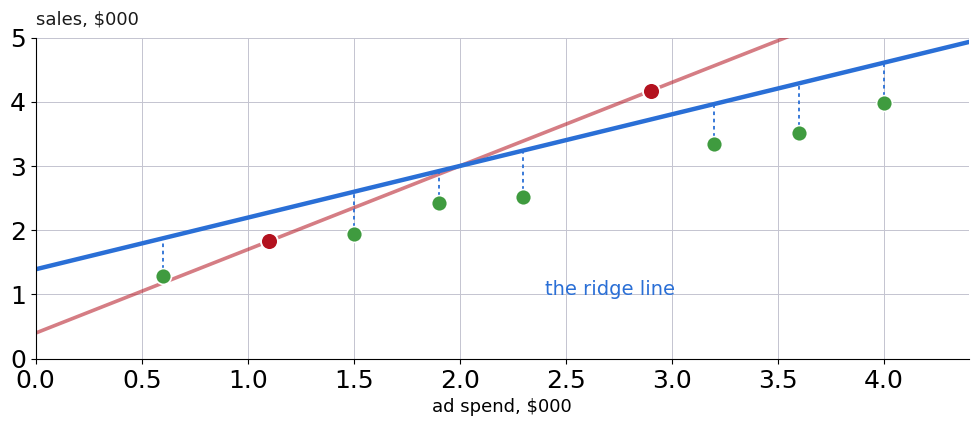

least squares slope 1.30, ridge slope 0.80
on the seven months it never saw:
   least squares   7.68
   ridge           2.93


In [138]:
fig, ax = panel()
firm_axes(ax)
grid = np.linspace(0, 4.4, 50)
xt, yt = AD[TWO], SALES[TWO]
xm, ym = xt.mean(), yt.mean()
b_ridge = ((xt - xm) @ (yt - ym)) / (((xt - xm) ** 2).sum() + 1.0)   # lambda = 1
a_ridge = ym - b_ridge * xm
ax.plot(grid, TR_A + TR_B * grid, color=LSQ, lw=2.6, alpha=0.55)
ax.plot(grid, a_ridge + b_ridge * grid, color=RIDGE, lw=3.2)
rest = np.array([i for i in range(len(AD)) if i not in TWO])
ax.scatter(AD[rest], SALES[rest], s=130, color=TEST, edgecolors="white", lw=1.2, zorder=5)
ax.scatter(xt, yt, s=150, color=LSQ, edgecolors="white", lw=1.4, zorder=6)
for i in rest:
    ax.plot([AD[i], AD[i]], [SALES[i], a_ridge + b_ridge * AD[i]], color=RIDGE,
            lw=1.3, ls=(0, (2, 2)))
ax.text(2.4, 1.0, "the ridge line", color=RIDGE, fontsize=14)
plt.show()

print("least squares slope %.2f, ridge slope %.2f" % (TR_B, b_ridge))
print("on the seven months it never saw:")
print("   least squares %6.2f" % np.sum((SALES[rest] - (TR_A + TR_B * AD[rest])) ** 2))
print("   ridge         %6.2f" % np.sum((SALES[rest] - (a_ridge + b_ridge * AD[rest])) ** 2))

## How It Works

Least squares picks the parameters that minimize

$$\text{the sum of the squared residuals}$$

Ridge regression picks the parameters that minimize

$$\text{the sum of the squared residuals} \;+\; \lambda \times \text{the slope}^2$$

The second term is a <b style="color:#73000A;">penalty on the slope</b>. And $\lambda$ decides
<b style="color:#73000A;">how severe that penalty is</b>.

### Score Both Lines

Put $\lambda = 1$ and work out the score for each line.

<b style="color:#73000A;">The least squares line</b>, slope $1.3$. It runs through both months, so the residuals
are zero:

$$0 \;+\; 1 \times 1.3^2 \;=\; 1.69$$

<b style="color:#73000A;">The ridge line</b>, slope $0.80$. It misses each month by $0.45$:

$$\big(0.45^2 + 0.45^2\big) \;+\; 1 \times 0.80^2 \;=\; 0.40 + 0.65 \;=\; 1.04$$

Minimizing the sum of squared residuals plus the penalty, we would
<b style="color:#73000A;">choose the ridge line</b>.

In [139]:
xt, yt = AD[TWO], SALES[TWO]
xm, ym = xt.mean(), yt.mean()
lam = 1.0
b_r = ((xt - xm) @ (yt - ym)) / (((xt - xm) ** 2).sum() + lam)
a_r = ym - b_r * xm

print("%-22s %10s %10s %10s" % ("", "SSR", "penalty", "total"))
print("%-22s %10s %10s %10s" % ("-" * 22, "-" * 10, "-" * 10, "-" * 10))
for name, a, b in (("least squares line", TR_A, TR_B), ("ridge line", a_r, b_r)):
    ssr = float(np.sum((yt - (a + b * xt)) ** 2))
    print("%-22s %10.2f %10.2f %10.2f" % (name, ssr, lam * b ** 2, ssr + lam * b ** 2))
print()
print("the ridge line's residuals: %s" % np.round(yt - (a_r + b_r * xt), 2))

                              SSR    penalty      total
---------------------- ---------- ---------- ----------
least squares line           0.00       1.69       1.69
ridge line                   0.40       0.65       1.04

the ridge line's residuals: [-0.45  0.45]


### Why the Slope Is the Right Thing to Penalize

A slope is just a <b style="color:#73000A;">marginal effect</b>: how much the outcome moves when the regressor moves by one unit.

- Large slope: one more thousand of ad spend moves predicted sales a lot. Predictions are <b style="color:#73000A;">highly responsive to ad spend</b>
- Small slope: the same extra thousand barely moves the prediction

<b style="color:#73000A;">Ridge deliberately understates the marginal effect</b> relative to least squares, trading a little bias for a lot less variance.

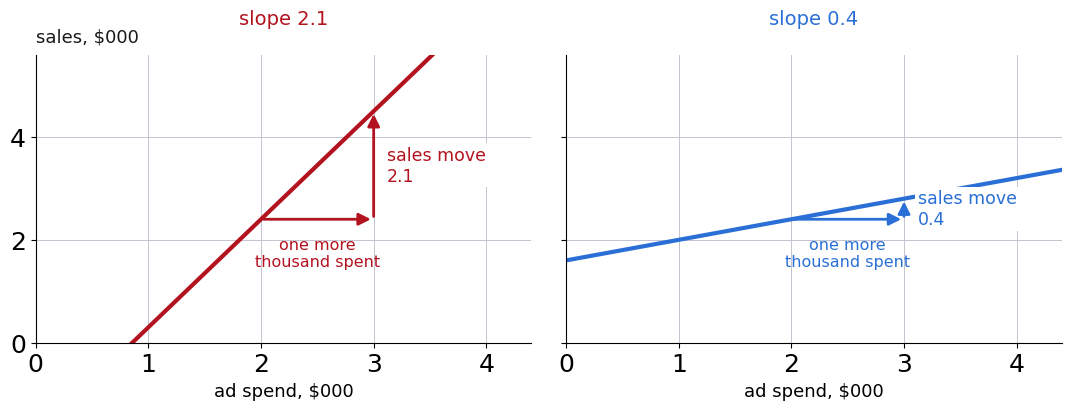

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3), sharey=True)
fig.subplots_adjust(left=0.08, right=0.98, top=0.84, bottom=0.17, wspace=0.07)

for ax, slope, col in ((axes[0], 2.1, LSQ), (axes[1], 0.4, RIDGE)):
    grid = np.linspace(0, 4.4, 50)
    ax.plot(grid, 2.4 + slope * (grid - 2), color=col, lw=3)

    lo, hi = 2.4, 2.4 + slope                      # the line at 2 and at 3
    ax.annotate("", xy=(3, lo), xytext=(2, lo),
                arrowprops=dict(arrowstyle="-|>", color=col, lw=2))
    ax.annotate("", xy=(3, hi), xytext=(3, lo),
                arrowprops=dict(arrowstyle="-|>", color=col, lw=2))
    ax.plot([3, 3], [lo, hi], color=col, lw=0)      # keeps the pair aligned
    ax.text(2.5, lo - 0.34, "one more\nthousand spent", color=col, fontsize=11.5,
            ha="center", va="top")
    ax.text(3.12, (lo + hi) / 2, "sales move\n%.1f" % slope, color=col,
            fontsize=12.5, va="center",
            bbox=dict(facecolor="white", edgecolor="none", pad=2.0))

    ax.set_title("slope %.1f" % slope, fontsize=14, color=col, pad=22)
    ax.set_xlim(0, 4.4); ax.set_ylim(0, 5.6)
    ax.set_xlabel("ad spend, $000", fontsize=13)
    ax.grid(True, color=GRID, lw=0.7); ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].text(0.0, 1.03, "sales, $000", transform=axes[0].transAxes, ha="left",
             va="bottom", fontsize=13, color=INK)
plt.show()

## Bias-Variance Tradeoff

<div style="position: relative; margin-top: 20px;">

  <div style="margin-bottom: 45px;">
    <ul style="margin: 0;">
      <li>This is an example of where we have to trade off bias against variance</li>
    </ul>
    <div style="margin-left: 60px; color: #73000A; font-style: italic;">
      &#8593; This is the version of the bias-variance tradeoff data scientists think of
    </div>
  </div>

  <div>
    <ul style="margin: 0;">
      <li>We saw a different incarnation of this in the OLS lecture
        <ul>
          <li>"What if Z affected T a lot and Y just a little?"</li>
        </ul>
      </li>
    </ul>
    <div style="margin-left: 60px; color: #73000A; font-style: italic;">
      &#8593; This is the version economists think of
    </div>
  </div>

</div>

## What $\lambda$ Does

$\lambda$ can be <b style="color:#73000A;">any value from zero to positive infinity</b>.

- At $\lambda = 0$ the penalty is zero, so ridge regression <b style="color:#73000A;">is least squares</b>
- As $\lambda$ grows the slope gets smaller
- However large $\lambda$ gets, the slope only approaches zero
  <b style="color:#73000A;">asymptotically, and never arrives</b>

      lambda      slope
------------ ----------
           0      1.300
           1      0.804
           2      0.582
          10      0.181
      100000      0.000


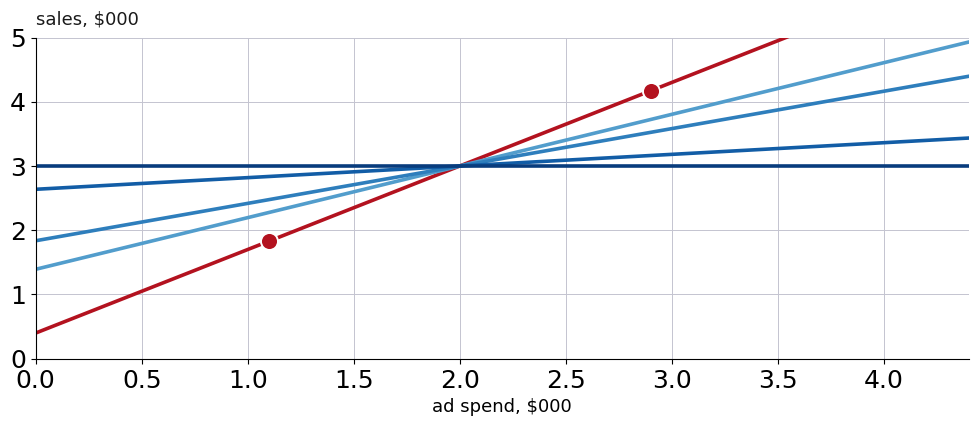

In [141]:
xt, yt = AD[TWO], SALES[TWO]
xm, ym = xt.mean(), yt.mean()
sxx, sxy = ((xt - xm) ** 2).sum(), (xt - xm) @ (yt - ym)

fig, ax = panel()
firm_axes(ax)
grid = np.linspace(0, 4.4, 50)
lams = [0.0, 1.0, 2.0, 10.0, 100000.0]
cols = plt.cm.Blues(np.linspace(0.45, 0.95, len(lams)))
print("%12s %10s" % ("lambda", "slope"))
print("%12s %10s" % ("-" * 12, "-" * 10))
for lam, col in zip(lams, cols):
    b = sxy / (sxx + lam)
    a = ym - b * xm
    ax.plot(grid, a + b * grid, color=(LSQ if lam == 0 else col), lw=2.6)
    print("%12g %10.3f" % (lam, b))
ax.scatter(xt, yt, s=150, color=LSQ, edgecolors="white", lw=1.4, zorder=6)
plt.show()

### So How Do You Choose $\lambda$?

Try a bunch of values and use <b style="color:#73000A;">cross validation</b>. Typically
<b style="color:#73000A;">ten fold</b>. Keep the value that gives the lowest variance.

## With Dummies

The same penalty works when the regressor is a <b style="color:#73000A;">yes or no variable</b>. Run an ad
campaign in some months and not others:

$$\text{sales} = \text{intercept} + \text{campaign difference} \times \text{campaign}$$

where campaign is 0 or 1. Then

- The intercept, $1.5$, is the <b style="color:#73000A;">average sales without a campaign</b>
- The coefficient, $0.7$, is the <b style="color:#73000A;">difference between the two averages</b>

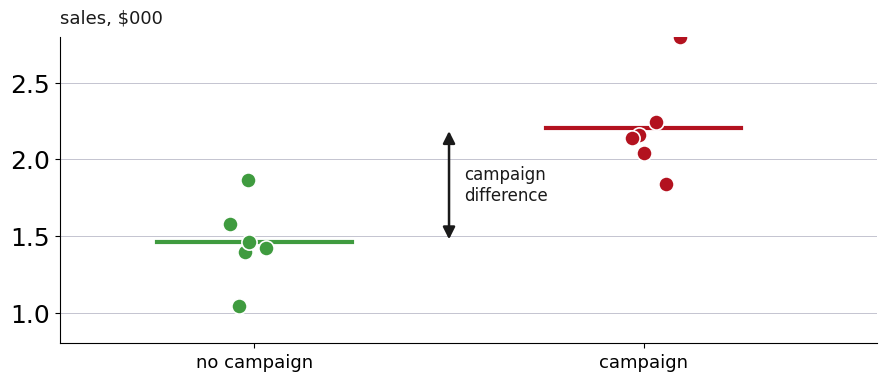

In [142]:
rng = np.random.default_rng(3)
no_camp = 1.5 + rng.normal(0, 0.18, 6)
camp = 2.2 + rng.normal(0, 0.18, 6)

fig, ax = plt.subplots(figsize=(9.4, 4.2))
fig.subplots_adjust(left=0.1, right=0.97, top=0.9, bottom=0.17)
ax.scatter(np.zeros(6) + 0.06 * rng.normal(size=6), no_camp, s=120, color=TEST,
           edgecolors="white", lw=1.2, zorder=5)
ax.scatter(np.ones(6) + 0.06 * rng.normal(size=6), camp, s=120, color=LSQ,
           edgecolors="white", lw=1.2, zorder=5)
ax.plot([-0.25, 0.25], [no_camp.mean()] * 2, color=TEST, lw=3)
ax.plot([0.75, 1.25], [camp.mean()] * 2, color=LSQ, lw=3)
ax.annotate("", xy=(0.5, camp.mean()), xytext=(0.5, no_camp.mean()),
            arrowprops=dict(arrowstyle="<|-|>", color=INK, lw=1.8))
ax.text(0.54, (camp.mean() + no_camp.mean()) / 2, "campaign\ndifference", fontsize=12,
        va="center", color=INK)
ax.set_xticks([0, 1]); ax.set_xticklabels(["no campaign", "campaign"], fontsize=13)
ax.set_xlim(-0.5, 1.6); ax.set_ylim(0.8, 2.8)
ax.text(0.0, 1.03, "sales, $000", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=13, color=INK)
ax.grid(True, axis="y", color=GRID, lw=0.7); ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

### Shrinking a Difference Between Groups

Ridge now minimizes

$$\text{the sum of the squared residuals} \;+\; \lambda \times \text{campaign difference}^2$$

- At $\lambda = 0$ this is least squares again
- As $\lambda$ grows, the only way to make the total small is to
  <b style="color:#73000A;">shrink the difference</b>
- So the prediction for a campaign month becomes <b style="color:#73000A;">less sensitive to whether there was a campaign</b>

### And It Works on Logistic Regression

Use ad spend to predict whether a customer <b style="color:#73000A;">buys or does not</b>.

Ridge shrinks the estimated slope, making the prediction less sensitive to ad
spend. One change: logistic regression is fitted by maximum likelihood, so ridge
penalizes

$$\text{the sum of the likelihoods} \;+\; \lambda \times \text{the slope}^2$$

### And on Complicated Models

Put both regressors in at once:

$$\text{sales} = \text{intercept} + \text{slope} \times \text{ad spend}
+ \text{campaign difference} \times \text{campaign}$$

Now the penalty carries both parameters:

$$\lambda \times \big(\text{slope}^2 + \text{campaign difference}^2\big)$$

In general the ridge penalty contains <b style="color:#73000A;">every parameter except the intercept</b>.

### Why the Intercept Is Left Out

Every parameter except the intercept is <b style="color:#73000A;">multiplied by a measurement</b>.

The intercept is not. It is the level of the outcome when everything else is
zero, and shrinking that toward zero would be bias bought for nothing.

## Solving the Unsolvable

Least squares needs <b style="color:#73000A;">at least as many data points as parameters</b>.

- A line has two parameters, so it needs two points. With one point, every line
  through it has zero residuals and there is <b style="color:#73000A;">no way to choose between them</b>
- Add a regressor and you are fitting a plane, which needs three points
- Four parameters need four data points
- <b style="color:#73000A;">10,001 parameters need 10,001 data points</b>

### Where That Bites

An equation with 10,001 parameters sounds absurd. It is not.

- 10,000 product characteristics measured across <b style="color:#73000A;">500 stores</b>
- Thousands of candidate controls in a panel with a few hundred units

Collecting 10,001 units is expensive and often impossible. So what do you do
with 10,001 parameters and 500 data points?

<b style="color:#73000A;">You use ridge regression.</b>

## Start With a Puzzle


$$\text{Two numbers add up to } 10. \quad \text{What are they?}$$

- 5 and 5
- 9 and 1
- 100 and $-90$

<b style="color:#73000A;">Every one of those is right</b>. 

 - One clue
 - two unknowns
 - infinitely many answers
 - No way to choose between them.

### Data Are Clues, Coefficients Are Unknowns

- Each <b style="color:#73000A;">row of data</b> is one clue
- Each <b style="color:#73000A;">coefficient you are estimating</b> is one unknown

Scale it up:
- Twenty observations and a hundred things to estimate is twenty clues and a hundred unknowns.

### Why Least Squares Is Stuck

Least squares has exactly one rule: <b style="color:#73000A;">pick the answer that misses the data by the least</b>.

But every one of those answers misses by <b style="color:#73000A;">zero</b>. The rule cannot
rank them. It is being asked which of several perfect answers is the most
perfect.


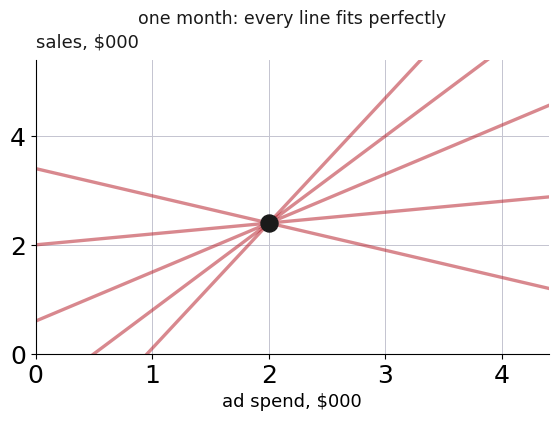

In [143]:
fig, ax = plt.subplots(figsize=(5.7, 4.2))
fig.subplots_adjust(left=0.08, right=0.98, top=0.86, bottom=0.16)

grid = np.linspace(0, 4.4, 50)
for s in (-0.5, 0.2, 0.9, 1.6, 2.3):
    ax.plot(grid, 2.4 + s * (grid - 2), color=LSQ, lw=2.4, alpha=0.5)

ax.scatter([2], [2.4], s=150, color=INK, zorder=6)
firm_axes(ax, ymax=5.4)
ax.set_title("one month: every line fits perfectly", fontsize=12.5, color=INK, pad=26)
plt.show()

### So Add a Tiebreaker

A second rule, on top of the first: of all the pairs that add up to 10,
<b style="color:#73000A;">take the pair whose numbers are smallest</b>.

Smallest how? <b style="color:#73000A;">Square each number and add the two squares up.</b>
The pair with the smallest total wins.

In [144]:
print("two numbers that add up to 10")
print()
print("%12s %12s %16s" % ("first", "second", "squares added up"))
print("%12s %12s %16s" % ("-" * 10, "-" * 10, "-" * 14))
for first in (5, 9, 0, 100, -20):
    second = 10 - first
    print("%12d %12d %16d" % (first, second, first ** 2 + second ** 2))
print()

two numbers that add up to 10

       first       second squares added up
  ----------   ----------   --------------
           5            5               50
           9            1               82
           0           10              100
         100          -90            18100
         -20           30             1300



### Why There Is One Winner

Start at 5 and 5 and walk away from it. Add $t$ to the first and take $t$ off
the second, so the pair is $5+t$ and $5-t$ and <b style="color:#73000A;">still adds to 10</b>.

Square them and add:

$$(5+t)^2 + (5-t)^2 \;=\; 25 + 10t + t^2 \;+\; 25 - 10t + t^2 \;=\; \color{#73000A}{\mathbf{50 + 2t^2}}$$

The $10t$ and the $-10t$ <b style="color:#73000A;">cancel</b>. Whatever $t$ you choose you pay $2t^2$
extra, and that is positive unless $t$ is zero.

Move either way and you are worse off.

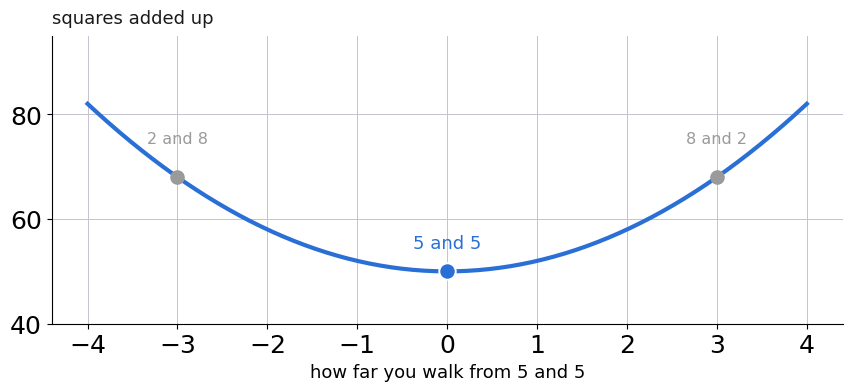

In [145]:
t = np.linspace(-4, 4, 200)
cost = 50 + 2 * t ** 2

fig, ax = plt.subplots(figsize=(9.2, 4.0))
fig.subplots_adjust(left=0.11, right=0.97, top=0.9, bottom=0.18)
ax.plot(t, cost, color=RIDGE, lw=3)
ax.scatter([0], [50], s=140, color=RIDGE, zorder=6, edgecolors="white", lw=1.4)
ax.text(0.0, 54.5, "5 and 5", color=RIDGE, fontsize=13, ha="center")
for tv in (-3, 3):
    ax.scatter([tv], [50 + 2 * tv ** 2], s=90, color=GREY, zorder=5)
    ax.text(tv, 50 + 2 * tv ** 2 + 6, "%d and %d" % (5 + tv, 5 - tv), color=GREY,
            fontsize=11.5, ha="center", va="bottom")
ax.set_xlabel("how far you walk from 5 and 5", fontsize=13)
ax.text(0.0, 1.03, "squares added up", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=13, color=INK)
ax.grid(True, color=GRID, lw=0.7); ax.set_axisbelow(True)
ax.set_ylim(40, 95)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

### Now the Same Puzzle, as a Regression

- The clue becomes a month of data
- The two numbers become two coefficients
- Adding up to 10 becomes fitting the month

### Two Things You Spent On This Month

$$\text{sales}_i \;=\; b_{\text{ads}}\,\text{ads}_i \;+\; b_{\text{display}}\,\text{display}_i$$

The month: 2 on ads, 1 on displays, sales up 5. Put those in and

$$2\,b_{\text{ads}} \;+\; 1\,b_{\text{display}} \;=\; 5$$

<b style="color:#73000A;">One equation, two unknowns</b>.

*(No intercept: it keeps the picture two-dimensional, and an unpenalized
intercept would trivially absorb our single observation.)*

### A Whole Line of Right Answers

Any pair on that equation reproduces the month.

- 2 on ads and 1 on displays: $2(2) + 1 = 5$
- 2.5 on ads and 0 on displays: $2(2.5) + 0 = 5$
- 0 on ads and 5 on displays: $2(0) + 5 = 5$

Least squares wants the pair that misses by the least. All of these miss by
<b style="color:#73000A;">nothing at all</b>, so it <b style="color:#73000A;">cannot choose</b>.

### Score Them the Way We Scored 5 and 5

Square each coefficient, add the two squares, <b style="color:#73000A;">smallest total wins</b>.

Same rule as the two numbers adding to 10, and this one has a name:
<b style="color:#73000A;">the ridge penalty</b>.

In [146]:
print("pairs that fit the month:  2 x b_ads  +  b_display  =  5")
print()
print("%10s %12s %16s" % ("b_ads", "b_display", "squares added up"))
print("%10s %12s %16s" % ("-" * 8, "-" * 10, "-" * 14))
for b_ads in (0.0, 1.0, 2.0, 2.5, 3.0):
    b_disp = 5 - 2 * b_ads                       # stay on the line
    print("%10.2f %12.2f %16.2f" % (b_ads, b_disp, b_ads ** 2 + b_disp ** 2))
print()
print("smallest: 5.00, at 2 on ads and 1 on displays")

pairs that fit the month:  2 x b_ads  +  b_display  =  5

     b_ads    b_display squares added up
  --------   ----------   --------------
      0.00         5.00            25.00
      1.00         3.00            10.00
      2.00         1.00             5.00
      2.50         0.00             6.25
      3.00        -1.00            10.00

smallest: 5.00, at 2 on ads and 1 on displays


### Why That One and No Other

Start at 2 and 1 and slide along the line. Add $t$ to ads and take $2t$ off
displays, so the pair is $(2 + t,\; 1 - 2t)$ and <b style="color:#73000A;">still fits the month</b>.

$$(2+t)^2 + (1-2t)^2 \;=\; 4 + 4t + t^2 \;+\; 1 - 4t + 4t^2 \;=\; \color{#73000A}{\mathbf{5 + 5t^2}}$$

The $4t$ and the $-4t$ <b style="color:#73000A;">cancel</b>, exactly as the $10t$ terms did in the puzzle.
Any step away from $t = 0$ costs you $5t^2$, so 2 and 1 is
<b style="color:#73000A;">the only winner there is</b>.

### The Same Steps, Side by Side

Both problems, <b style="color:#73000A;">worked at the same time</b>. The puzzle on the left, the month on the
right.

The score is what ridge is trying to make small:

$$\text{score} \;=\; (\text{how much you miss})^2 \;+\; \lambda \times (\text{squares added up})$$

Left half is <b style="color:#73000A;">least squares</b>. Right half is
<b style="color:#73000A;">ridge</b>. Set <b style="color:#73000A;">$\lambda = 1$</b> and see what happens.

In [147]:
W = "%-11s %-28s %-28s"
lam       = 1.0                                   # the dial, set by hand for now
puzzle    = [(5.0, 5.0), (9.0, 1.0), (0.0, 10.0)]
the_month = [(2.0, 1.0), (2.5, 0.0), (0.0,  5.0)]

def miss_puzzle(a, b):   return a + b - 10        # what the clue asked for
def miss_month(x, y):    return 2 * x + y - 5
def score(miss, u, v):   return miss ** 2 + lam * (u ** 2 + v ** 2)

print(W % ("", "THE PUZZLE", "THE MONTH"))
print(W % ("", "-" * 26, "-" * 26))
print(W % ("the clue", "a + b = 10", "2*b_ads + b_disp = 5"))
print(W % ("unknowns", "a and b", "b_ads and b_disp"))
print()
print("step 1.  by how much does each answer miss?")
for (a, b), (x, y) in zip(puzzle, the_month):
    print(W % ("", "(%4.1f,%5.1f)  misses %5.2f" % (a, b, abs(miss_puzzle(a, b))),
                   "(%4.1f,%5.1f)  misses %5.2f" % (x, y, abs(miss_month(x, y)))))
print(W % ("", "nothing to choose from", "nothing to choose from"))
print()
print("step 2.  score them:  miss^2 + lambda x (squares added up),  lambda = %.2f" % lam)
for (a, b), (x, y) in zip(puzzle, the_month):
    print(W % ("", "(%4.1f,%5.1f)  scores %6.2f" % (a, b, score(miss_puzzle(a, b), a, b)),
                   "(%4.1f,%5.1f)  scores %6.2f" % (x, y, score(miss_month(x, y), x, y))))
print(W % ("", "5 and 5 wins", "2 ads, 1 displays wins"))

            THE PUZZLE                   THE MONTH                   
            --------------------------   --------------------------  
the clue    a + b = 10                   2*b_ads + b_disp = 5        
unknowns    a and b                      b_ads and b_disp            

step 1.  by how much does each answer miss?
            ( 5.0,  5.0)  misses  0.00   ( 2.0,  1.0)  misses  0.00  
            ( 9.0,  1.0)  misses  0.00   ( 2.5,  0.0)  misses  0.00  
            ( 0.0, 10.0)  misses  0.00   ( 0.0,  5.0)  misses  0.00  
            nothing to choose from       nothing to choose from      

step 2.  score them:  miss^2 + lambda x (squares added up),  lambda = 1.00
            ( 5.0,  5.0)  scores  50.00  ( 2.0,  1.0)  scores   5.00 
            ( 9.0,  1.0)  scores  82.00  ( 2.5,  0.0)  scores   6.25 
            ( 0.0, 10.0)  scores 100.00  ( 0.0,  5.0)  scores  25.00 
            5 and 5 wins                 2 ads, 1 displays wins      


### The Results

The pair that won is <b style="color:#73000A;">$b_{\text{ads}} = 2$ and $b_{\text{display}} = 1$</b>, so the estimated
model is

$$\widehat{\text{sales}} \;=\; 2 \times \text{ads} \;+\; 1 \times \text{displays}$$

- A dollar more on ads moves sales by <b style="color:#73000A;">2</b>
- A dollar more on displays moves sales by <b style="color:#73000A;">1</b>

In [148]:
b_ads, b_display = 2.0, 1.0                  # what step 2 handed back

print("the estimated model:  sales = %.1f x ads  +  %.1f x displays" % (b_ads, b_display))
print()
print("%14s %12s %16s" % ("ads", "displays", "sales predicted"))
print("%14s %12s %16s" % ("-" * 12, "-" * 10, "-" * 14))
for ads, displays, note in ((2.0, 1.0, "the month we saw"),
                            (3.0, 2.0, "a bigger month"),
                            (1.0, 0.0, "ads only"),
                            (0.0, 4.0, "displays only")):
    print("%14.1f %12.1f %16.2f   %s"
          % (ads, displays, b_ads * ads + b_display * displays, note))
print()
print("   the month we saw comes back as 5.00, which is what happened")

the estimated model:  sales = 2.0 x ads  +  1.0 x displays

           ads     displays  sales predicted
  ------------   ----------   --------------
           2.0          1.0             5.00   the month we saw
           3.0          2.0             8.00   a bigger month
           1.0          0.0             2.00   ads only
           0.0          4.0             4.00   displays only

   the month we saw comes back as 5.00, which is what happened


### Does the Winner Depend on What $\lambda$ Is?

Among the answers that fit exactly, <b style="color:#73000A;">no</b>.

Each of them misses by nothing, so the left half of the score is zero and what
is left is $\lambda$ times the same ranking. Turning $\lambda$ up multiplies every
score by the same number, and <b style="color:#73000A;">multiplying does not change who is smallest</b>.

So <b style="color:#73000A;">any $\lambda$ above zero</b> picks one answer out of infinitely many, and they
all pick <b style="color:#73000A;">the same one</b>.

In [149]:
print("step 3.  among the pairs that fit exactly, which one scores best?")
print()
print("%10s %26s %26s" % ("lambda", "best fit, THE PUZZLE", "best fit, THE MONTH"))
print("%10s %26s %26s" % ("-" * 8, "-" * 24, "-" * 24))
for lam in (0.01, 1.0, 100.0):
    a = np.linspace(-5, 15, 20001);  b = 10 - a          # every pair adding to 10
    p = int(np.argmin((a + b - 10) ** 2 + lam * (a ** 2 + b ** 2)))
    x = np.linspace(-5, 10, 20001);  y = 5 - 2 * x       # every pair fitting the month
    m = int(np.argmin((2 * x + y - 5) ** 2 + lam * (x ** 2 + y ** 2)))
    print("%10.2f %26s %26s"
          % (lam, "(%.2f, %.2f)" % (a[p], b[p]), "(%.2f, %.2f)" % (x[m], y[m])))
print()
print("   same winner every time, only the size of the score changes")

step 3.  among the pairs that fit exactly, which one scores best?

    lambda       best fit, THE PUZZLE        best fit, THE MONTH
  --------   ------------------------   ------------------------
      0.01               (5.00, 5.00)               (2.00, 1.00)
      1.00               (5.00, 5.00)               (2.00, 1.00)
    100.00               (5.00, 5.00)               (2.00, 1.00)

   same winner every time, only the size of the score changes


### And What $\lambda$ Does, on Both Sides

$\lambda$ is <b style="color:#73000A;">how loudly the tiebreaker gets to speak</b>.

- Turned all the way down it only whispers, and <b style="color:#73000A;">a whisper is still enough to pick one</b>
- Turn it up and <b style="color:#73000A;">fitting the data stops being worth the cost</b>, so both answers shrink
- Turn it far enough and everything goes to zero

Same knob, same effect, both problems.

In [150]:
W = "%-11s %-28s %-28s"

print("step 4.  turn lambda up and watch both answers shrink")
print()
print(W % ("lambda", "THE PUZZLE", "THE MONTH"))
print(W % ("", "-" * 26, "-" * 26))
for lam in (0.0, 1.0, 5.0, 20.0):
    p = Ridge(alpha=max(lam, 1e-9), fit_intercept=False).fit(np.array([[1.0, 1.0]]),
                                                             np.array([10.0])).coef_
    m = Ridge(alpha=max(lam, 1e-9), fit_intercept=False).fit(np.array([[2.0, 1.0]]),
                                                             np.array([5.0])).coef_
    print(W % ("%6.2f" % lam,
               "(%5.2f,%6.2f)  gives %5.2f" % (p[0], p[1], p[0] + p[1]),
               "(%5.2f,%6.2f)  gives %5.2f" % (m[0], m[1], 2 * m[0] + m[1])))
print(W % ("wanted", "10.00", "5.00"))
print()
print(W % ("by hand", "10/(2+lam) x (1, 1)", "5/(5+lam) x (2, 1)"))
print(W % ("", "ratio stays 1 to 1", "ratio stays 2 to 1"))
print()
print("   nothing is dropped and nothing is reshuffled, the pair just shrinks")

step 4.  turn lambda up and watch both answers shrink

lambda      THE PUZZLE                   THE MONTH                   
            --------------------------   --------------------------  
  0.00      ( 5.00,  5.00)  gives 10.00  ( 2.00,  1.00)  gives  5.00 
  1.00      ( 3.33,  3.33)  gives  6.67  ( 1.67,  0.83)  gives  4.17 
  5.00      ( 1.43,  1.43)  gives  2.86  ( 1.00,  0.50)  gives  2.50 
 20.00      ( 0.45,  0.45)  gives  0.91  ( 0.40,  0.20)  gives  1.00 
wanted      10.00                        5.00                        

by hand     10/(2+lam) x (1, 1)          5/(5+lam) x (2, 1)          
            ratio stays 1 to 1           ratio stays 2 to 1          

   nothing is dropped and nothing is reshuffled, the pair just shrinks


### The Same Thing as a Picture

Both axes are <b style="color:#73000A;">the two coefficients</b>.

The dark line is <b style="color:#73000A;">the month's data</b>. Every pair on it fits:

$$2\,b_{\text{ads}} \;+\; 1\,b_{\text{display}} \;=\; 5$$

The rings are <b style="color:#73000A;">the penalty</b>. Every pair on one ring costs the same $c$:

$$b_{\text{ads}}^{2} \;+\; b_{\text{display}}^{2} \;=\; c$$

Grow $c$ from nothing. The ring first reaches the line at
<b style="color:#73000A;">2 on ads and 1 on displays</b>, where $c = 2^2 + 1^2 = 5$.

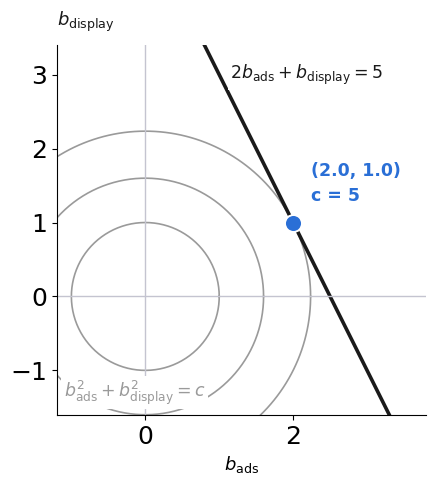

In [151]:
fig, ax = plt.subplots(figsize=(6.4, 5.6))
fig.subplots_adjust(left=0.12, right=0.97, top=0.80, bottom=0.14)

b1 = np.linspace(-1.2, 3.8, 200)
perfect = 5 - 2 * b1                                   # the month, rearranged
ring = np.linspace(0, 2 * np.pi, 400)

for r in (1.0, 1.6, np.sqrt(5)):                       # the last one just touches
    ax.plot(r * np.cos(ring), r * np.sin(ring), color=GREY, lw=1.2)

ax.plot(b1, perfect, color=INK, lw=2.6)
ax.scatter([2.0], [1.0], s=150, color=RIDGE, zorder=6, edgecolors="white", lw=1.4)
ax.text(2.24, 1.24, "(2.0, 1.0)\nc = 5", color=RIDGE, fontsize=12.5,
        weight="bold", va="bottom", linespacing=1.5)

ax.text(1.15, 3.0, r"$2b_{\mathrm{ads}} + b_{\mathrm{display}} = 5$", color=INK,
        fontsize=12.5, va="center",
        bbox=dict(facecolor="white", edgecolor="none", pad=2.0))
ax.text(-1.1, -1.3, r"$b_{\mathrm{ads}}^{2} + b_{\mathrm{display}}^{2} = c$", color=GREY,
        fontsize=12.5, va="center",
        bbox=dict(facecolor="white", edgecolor="none", pad=2.0))

ax.set_xlim(-1.2, 3.8); ax.set_ylim(-1.6, 3.4)
ax.set_aspect("equal", adjustable="box")
ax.axhline(0, color=GRID, lw=1); ax.axvline(0, color=GRID, lw=1)
ax.set_xlabel(r"$b_{\mathrm{ads}}$", fontsize=13)
ax.text(0.0, 1.03, r"$b_{\mathrm{display}}$", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=13, color=INK)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

### What the Software Returns

With the penalty barely switched on, ridge hands back
<b style="color:#73000A;">2 on ads and 1 on displays</b>, the pair we picked off the table by hand.

Turn $\lambda$ up and it gives back a little fit to buy a lot less penalty, so
it slides <b style="color:#73000A;">straight toward zero</b>.

In [152]:
from sklearn.linear_model import Ridge

X_one = np.array([[2.0, 1.0]])         # one month: 2 on ads, 1 on displays
y_one = np.array([5.0])                # sales up 5

print("%14s %22s" % ("lambda", "ridge"))
print("%14s %22s" % ("-" * 12, "-" * 20))
for lam in (0.000001, 0.1, 1.0):
    r = Ridge(alpha=lam, fit_intercept=False).fit(X_one, y_one).coef_
    print("%14g %22s" % (lam, "(%.3f, %.3f)" % (r[0], r[1])))

        lambda                  ridge
  ------------   --------------------
         1e-06         (2.000, 1.000)
           0.1         (1.961, 0.980)
             1         (1.667, 0.833)


### Where It Goes as $\lambda$ Grows

With one month you can write the whole path down:

$$\hat b(\lambda) \;=\; \frac{5}{5 + \lambda}\,\big(2,\;\; 1\big)$$

- $\lambda = 0$: $(2.000,\; 1.000)$, sitting on the line, month reproduced exactly
- $\lambda = 1$: $(1.667,\; 0.833)$, predicts 4.17 instead of 5
- $\lambda = 5$: $(1.000,\; 0.500)$, half way to nothing

Both coefficients are multiplied by <b style="color:#73000A;">the same number</b>, so the pair
walks <b style="color:#73000A;">a straight line into zero</b> and the two to one ratio never changes.

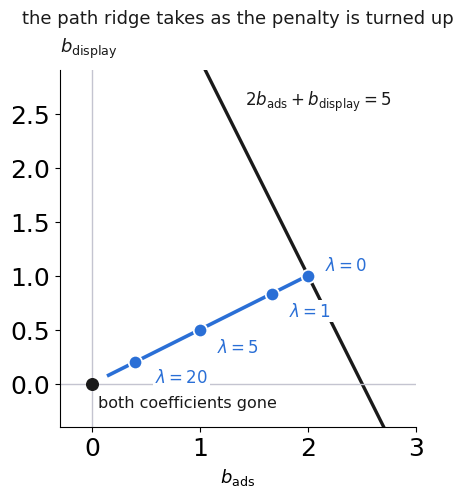

In [153]:
fig, ax = plt.subplots(figsize=(6.4, 5.4))
fig.subplots_adjust(left=0.12, right=0.97, top=0.80, bottom=0.14)

b1 = np.linspace(-0.3, 3.0, 200)
ax.plot(b1, 5 - 2 * b1, color=INK, lw=2.4)              # the month
ax.text(1.42, 2.62, r"$2b_{\mathrm{ads}} + b_{\mathrm{display}} = 5$", color=INK,
        fontsize=12, va="center",
        bbox=dict(facecolor="white", edgecolor="none", pad=2.0))

lam = np.linspace(0, 60, 400)
ax.plot(10 / (5 + lam), 5 / (5 + lam), color=RIDGE, lw=2.6)   # the whole path

for value, dx, dy in ((0.0, 0.16, 0.10), (1.0, 0.16, -0.16),
                      (5.0, 0.16, -0.16), (20.0, 0.18, -0.14)):
    x, y = 10 / (5 + value), 5 / (5 + value)
    ax.scatter([x], [y], s=95, color=RIDGE, zorder=6, edgecolors="white", lw=1.3)
    ax.text(x + dx, y + dy, r"$\lambda = %g$" % value, color=RIDGE, fontsize=12,
            va="center", bbox=dict(facecolor="white", edgecolor="none", pad=1.5))

ax.scatter([0], [0], s=70, color=INK, zorder=6)
ax.text(0.06, -0.22, "both coefficients gone", color=INK, fontsize=11.5)

ax.set_xlim(-0.3, 3.0); ax.set_ylim(-0.4, 2.9)
ax.set_aspect("equal", adjustable="box")
ax.axhline(0, color=GRID, lw=1); ax.axvline(0, color=GRID, lw=1)
ax.set_xlabel(r"$b_{\mathrm{ads}}$", fontsize=13)
ax.text(0.0, 1.03, r"$b_{\mathrm{display}}$", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=13, color=INK)
ax.set_title("the path ridge takes as the penalty is turned up", fontsize=13,
             color=INK, pad=34)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

### And It Holds Up at Full Size

Twenty months and one hundred things the shop spends on, so ninety eight
<b style="color:#73000A;">more unknowns than clues</b>. Spending categories move together, the way
they do in a real budget.


In [154]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

rng = np.random.default_rng(5)
n, p = 20, 100
truth = rng.normal(0, 0.3, p)                    # everything matters a little

def a_budget(months):                            # categories that move together
    mood = rng.normal(size=(months, 5))          # five things driving the budget
    return mood @ rng.normal(size=(5, p)) * 0.9 + rng.normal(size=(months, p)) * 0.1

spend = a_budget(n)
sales = spend @ truth + rng.normal(0, 1.0, n)
spend_new = a_budget(500)
sales_new = spend_new @ truth + rng.normal(0, 1.0, 500)

ridge = GridSearchCV(Ridge(), {"alpha": np.logspace(-3, 5, 80)}, cv=5).fit(spend, sales)

print("%-22s %16s %22s" % ("", "the 20 months", "the next 500 months"))
print("%-22s %16s %22s" % ("-" * 22, "-" * 14, "-" * 20))
for name, m in (("least squares", LinearRegression().fit(spend, sales)), ("ridge", ridge)):
    print("%-22s %16.3f %22.3f" % (name, np.mean((sales - m.predict(spend)) ** 2),
                                   np.mean((sales_new - m.predict(spend_new)) ** 2)))
print("%-22s %16s %22.3f" % ("guess the average", "", np.mean((sales_new - sales.mean()) ** 2)))
print()
print("cross validation picked lambda = %.1f" % ridge.best_params_["alpha"])

                          the 20 months    the next 500 months
----------------------   --------------   --------------------
least squares                     0.000                 58.279
ridge                             0.489                  4.665
guess the average                                        8.163

cross validation picked lambda = 8.9


## Ridge, in Summary

- When the sample is small, ridge <b style="color:#73000A;">improves predictions made from new data</b>
  by making them less sensitive to the training data
- It does that by adding the penalty to the thing being minimized
- The penalty is $\lambda$ times the sum of the squared parameters,
  <b style="color:#73000A;">except the intercept</b>
- $\lambda$ is chosen by <b style="color:#73000A;">cross validation</b>
- Even when there is not enough data for least squares, ridge
  <b style="color:#73000A;">still finds one</b>

## Lasso

Take the ridge penalty and, instead of squaring the slope,
<b style="color:#73000A;">take its absolute value</b>.

$$\text{the sum of the squared residuals} \;+\; \lambda \times |\,\text{the slope}\,|$$

Everything else carries over. $\lambda$ runs from zero to infinity and is chosen
by cross validation. Lasso also buys a little bias and sells a lot of variance.

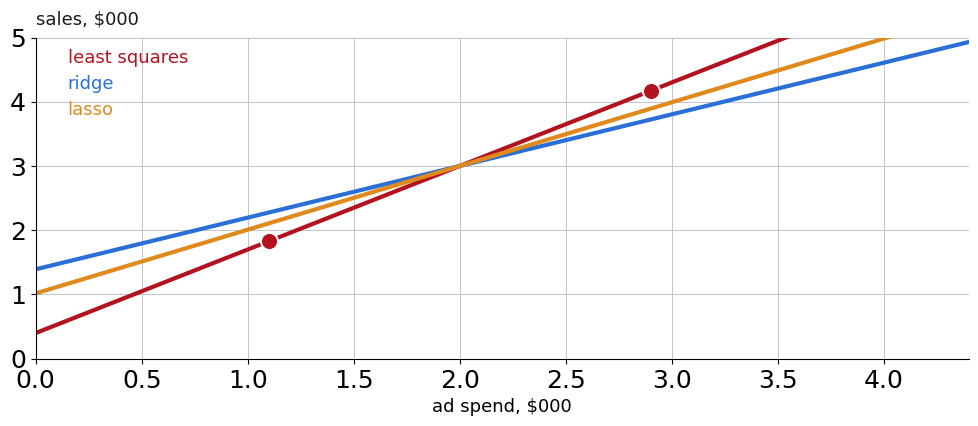

slopes:  least squares 1.30   ridge 0.80   lasso 0.99


In [155]:
fig, ax = panel()
firm_axes(ax)
grid = np.linspace(0, 4.4, 50)
xt, yt = AD[TWO], SALES[TWO]
xm, ym = xt.mean(), yt.mean()
sxx, sxy = ((xt - xm) ** 2).sum(), (xt - xm) @ (yt - ym)

b_ridge = sxy / (sxx + 1.0)
b_lasso = np.sign(sxy) * max(abs(sxy) - 1.0 / 2, 0) / sxx      # soft threshold
for b, col, lab in ((TR_B, LSQ, "least squares"), (b_ridge, RIDGE, "ridge"),
                    (b_lasso, LASSO, "lasso")):
    ax.plot(grid, (ym - b * xm) + b * grid, color=col, lw=3)
ax.scatter(xt, yt, s=150, color=LSQ, edgecolors="white", lw=1.4, zorder=6)
ax.text(0.15, 4.6, "least squares", color=LSQ, fontsize=13)
ax.text(0.15, 4.2, "ridge", color=RIDGE, fontsize=13)
ax.text(0.15, 3.8, "lasso", color=LASSO, fontsize=13)
plt.show()
print("slopes:  least squares %.2f   ridge %.2f   lasso %.2f" % (TR_B, b_ridge, b_lasso))

### The Big Difference

Turn $\lambda$ up and watch the slope.

- Ridge shrinks the slope <b style="color:#73000A;">asymptotically close to zero</b>
- Lasso shrinks it <b style="color:#73000A;">all the way to zero</b>

Once the slope is zero, the regressor is gone from the equation.

In [156]:
xt, yt = AD[TWO], SALES[TWO]
xm, ym = xt.mean(), yt.mean()
sxx, sxy = ((xt - xm) ** 2).sum(), (xt - xm) @ (yt - ym)

print("%10s %14s %14s" % ("lambda", "ridge slope", "lasso slope"))
print("%10s %14s %14s" % ("-" * 10, "-" * 14, "-" * 14))
for lam in (0.0, 1.0, 2.0, 5.0, 10.0, 100.0):
    b_r = sxy / (sxx + lam)
    b_l = np.sign(sxy) * max(abs(sxy) - lam / 2, 0) / sxx
    print("%10g %14.3f %14.3f" % (lam, b_r, b_l))

    lambda    ridge slope    lasso slope
---------- -------------- --------------
         0          1.300          1.300
         1          0.804          0.991
         2          0.582          0.683
         5          0.318          0.000
        10          0.181          0.000
       100          0.021          0.000


### Why That Matters

Write down a big, crazy equation for sales:

$$\text{sales} = \text{intercept} + \text{slope} \times \text{ad spend}
+ \text{difference} \times \text{campaign}$$
$$+ \;\text{something} \times \text{the CEO's star sign}
\;+\; \text{something} \times \text{the airspeed of a swallow}$$

- <b style="color:#73000A;">Ridge</b>: the useless terms shrink, a lot, and never leave
- <b style="color:#73000A;">Lasso</b>: the useless terms go to zero and <b style="color:#73000A;">drop out of the equation</b>

So lasso does a little better when a model is full of useless variables, and
ridge does a little better when <b style="color:#73000A;">most of the variables are useful</b>.

## Seeing the Difference

Take a simple dataset and try <b style="color:#73000A;">one slope after another</b>.

Plot the sum of the squared residuals against the slope you tried. The best
fitting line is <b style="color:#73000A;">at the bottom of the curve</b>.

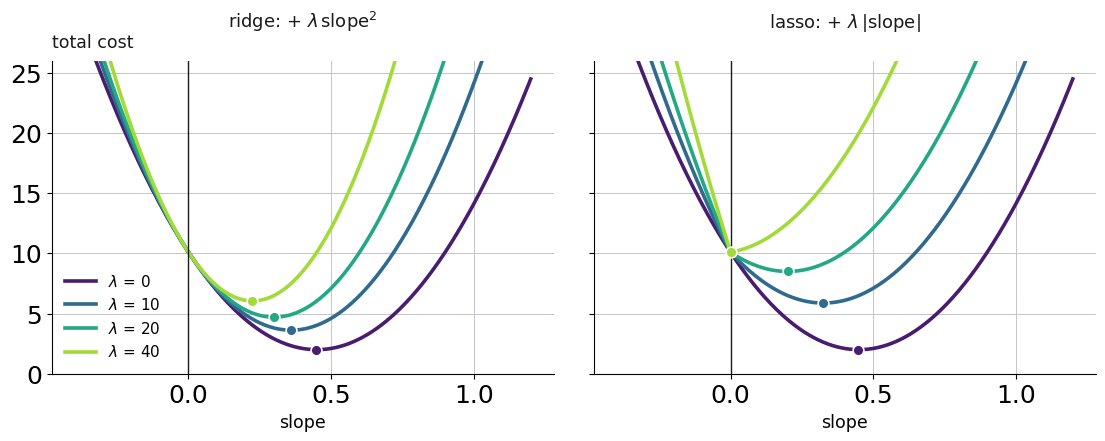

ridge   best slope at lambda 0, 10, 20, 40: [0.448 0.36  0.3   0.224]
lasso   best slope at lambda 0, 10, 20, 40: [0.448 0.324 0.2   0.   ]


In [157]:
b = np.linspace(-0.40, 1.20, 401)   # includes 0 exactly
A, BEST, FLOOR = 40.0, 0.45, 2.0
ssr = A * (b - BEST) ** 2 + FLOOR

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6), sharey=True)
fig.subplots_adjust(left=0.08, right=0.98, top=0.84, bottom=0.16, wspace=0.08)
lams = [0, 10, 20, 40]
cols = plt.cm.viridis(np.linspace(0.08, 0.86, len(lams)))
for ax, pen, ttl in ((axes[0], lambda l: l * b ** 2, "ridge: $+\\ \\lambda\\,$slope$^2$"),
                     (axes[1], lambda l: l * np.abs(b), "lasso: $+\\ \\lambda\\,|$slope$|$")):
    for lam, col in zip(lams, cols):
        total = ssr + pen(lam)
        ax.plot(b, total, color=col, lw=2.6, label="$\\lambda$ = %d" % lam)
        ax.scatter([b[np.argmin(total)]], [total.min()], s=60, color=col, zorder=6,
                   edgecolors="white", lw=1.2)
    ax.axvline(0, color=INK, lw=1.0)
    ax.set_xlabel("slope", fontsize=12.5)
    ax.set_title(ttl, fontsize=13, color=INK, pad=24)
    ax.grid(True, color=GRID, lw=0.7); ax.set_axisbelow(True)
    ax.set_ylim(0, 26)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].text(0.0, 1.03, "total cost", transform=axes[0].transAxes, ha="left",
             va="bottom", fontsize=12.5, color=INK)
axes[0].legend(frameon=False, fontsize=11)
plt.show()

for name, pen in (("ridge", lambda l: l * b ** 2), ("lasso", lambda l: l * np.abs(b))):
    best = [b[np.argmin(ssr + pen(l))] for l in lams]
    print("%-7s best slope at lambda 0, 10, 20, 40: %s" % (name, np.round(best, 3)))

## Elastic Net

Choosing between them is easy when you know what your variables are. With
millions of parameters you do not know, and <b style="color:#73000A;">some are useful and some are useless</b>.

So do not choose. Charge both prices at once:

$$\text{the sum of the squared residuals} \;+\; \lambda_1 \times |\,\text{the parameters}\,|
\;+\; \lambda_2 \times \text{the parameters}^2$$

### The Four Corners

- $\lambda_1 = 0$ and $\lambda_2 = 0$: <b style="color:#73000A;">least squares</b>
- $\lambda_1 > 0$ and $\lambda_2 = 0$: <b style="color:#73000A;">lasso</b>
- $\lambda_1 = 0$ and $\lambda_2 > 0$: <b style="color:#73000A;">ridge</b>
- both above zero: <b style="color:#73000A;">a mixture of the two</b>

Cross validation searches over pairs of them, so it can land anywhere in
between.

### What It Is Actually Good At

Variables that move together.

- On its own, lasso tends to <b style="color:#73000A;">pick just one of the correlated terms</b>
  and delete the others
- Ridge tends to <b style="color:#73000A;">shrink all of them together</b>
- Elastic net groups them, and then keeps the whole group or removes the whole
  group <b style="color:#73000A;">at once</b>

## Key Ideas

- Regularization buys a little <b style="color:#73000A;">bias</b> and sells a lot of
  <b style="color:#73000A;">variance</b>
- <b style="color:#73000A;">Ridge</b> adds $\lambda \times$ the squared parameters. Slopes shrink toward
  zero and never arrive
- <b style="color:#73000A;">Lasso</b> adds $\lambda \times$ the absolute parameters. Slopes reach zero, so
  useless variables drop out
- The penalty covers every parameter <b style="color:#73000A;">except the intercept</b>
- $\lambda$ comes from <b style="color:#73000A;">cross validation</b>
- Lasso is better when many variables are useless, ridge when most are useful,
  and <b style="color:#73000A;">elastic net</b> when you do not know
- With a penalty you can fit a model even when there are
  <b style="color:#73000A;">more parameters than data points</b>